In [76]:
import pandas as pd
import glob

In [77]:
# Tüm raw dosyalarını bul
raw_files = glob.glob("../data/raw/firms_*.csv")
print(f"Bulunan dosya sayısı: {len(raw_files)}")

Bulunan dosya sayısı: 15


In [78]:
dfs = []
for file in raw_files:
    df = pd.read_csv(file)
    if len(df) > 0:
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)
print(f"Toplam satır sayısı: {len(all_data)}")

Toplam satır sayısı: 1516


In [79]:
duplicate_count = all_data.duplicated(subset=['latitude', 'longitude', 'acq_date', 'acq_time']).sum()
print(f"Duplicate satır sayısı: {duplicate_count}")

Duplicate satır sayısı: 1056


In [80]:
duplicated_rows = all_data[all_data.duplicated(subset=['latitude', 'longitude', 'acq_date', 'acq_time'], keep=False)]
duplicated_rows.sort_values(['latitude', 'longitude']).head(10)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
94,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
243,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
511,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
660,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
809,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
1077,35.52656,44.34709,315.76,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,294.64,3.96,N
1150,35.52826,44.34174,367.00,0.33,0.55,2026-08-27,932,N,VIIRS,h,2.0NRT,321.34,10.08,D
1333,35.52826,44.34174,367.00,0.33,0.55,2026-08-27,932,N,VIIRS,h,2.0NRT,321.34,10.08,D
95,35.52826,44.34468,330.36,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,295.34,4.72,N
244,35.52826,44.34468,330.36,0.72,0.75,2026-08-26,11,N,VIIRS,n,2.0NRT,295.34,4.72,N


In [81]:
clean_data = all_data.drop_duplicates(subset=['latitude', 'longitude', 'acq_date', 'acq_time'], keep='first')
print(f"Temizlik öncesi: {len(all_data)}")
print(f"Temizlik sonrası: {len(clean_data)}")

Temizlik öncesi: 1516
Temizlik sonrası: 460


In [82]:
clean_data.to_csv("../data/processed/clean_hotspots.csv", index=False)
print(f"Kaydedildi: {len(clean_data)} satır")

Kaydedildi: 460 satır


In [83]:
#Genel yapı kontrolü
clean_data.info()
clean_data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 460 entries, 0 to 1332
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    460 non-null    float64
 1   longitude   460 non-null    float64
 2   bright_ti4  460 non-null    float64
 3   scan        460 non-null    float64
 4   track       460 non-null    float64
 5   acq_date    460 non-null    object 
 6   acq_time    460 non-null    int64  
 7   satellite   460 non-null    object 
 8   instrument  460 non-null    object 
 9   confidence  460 non-null    object 
 10  version     460 non-null    object 
 11  bright_ti5  460 non-null    float64
 12  frp         460 non-null    float64
 13  daynight    460 non-null    object 
dtypes: float64(7), int64(1), object(6)
memory usage: 53.9+ KB


,latitude,longitude,bright_ti4,scan,track,acq_time,bright_ti5,frp
count,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000,460.000000
mean,37.780005,37.915647,337.394326,0.487043,0.557652,686.836957,304.359848,8.057565
std,1.751819,5.130639,20.081873,0.121580,0.129525,491.440758,9.706340,9.143409
min,35.526560,25.638550,295.670000,0.320000,0.360000,9.000000,284.290000,0.330000
25%,36.455343,34.573470,318.512500,0.390000,0.440000,11.000000,295.552500,2.410000
50%,37.081635,38.720815,342.655000,0.450000,0.560000,943.000000,305.960000,5.850000
75%,39.024408,42.995585,350.207500,0.570000,0.670000,1115.000000,311.530000,9.915000
max,42.154980,44.428180,367.000000,0.790000,0.780000,1134.000000,325.740000,83.510000


In [84]:
#Coğrafi sınır kontrolü
print(f"Enlem aralığı: {clean_data['latitude'].min()} - {clean_data['latitude'].max()}")
print(f"Boylam aralığı: {clean_data['longitude'].min()} - {clean_data['longitude'].max()}")

Enlem aralığı: 35.52656 - 42.15498
Boylam aralığı: 25.63855 - 44.42818


In [85]:
#Confidence ve daynight dağılımı
print(clean_data['confidence'].value_counts())
print(clean_data['daynight'].value_counts())

confidence
n    399
h     61
Name: count, dtype: int64
daynight
D    302
N    158
Name: count, dtype: int64


<Axes: >

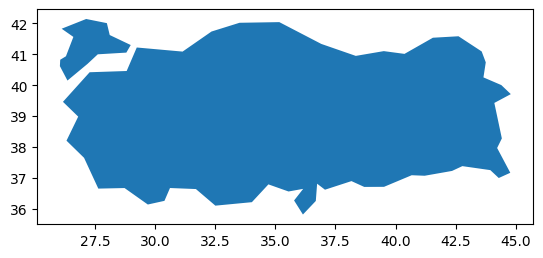

In [86]:
import geopandas as gpd

turkey_boundary = gpd.read_file("https://raw.githubusercontent.com/johan/world.geo.json/master/countries/TUR.geo.json")
turkey_boundary.plot()

In [87]:
#DataFrame'i GeoDataFrame'e çevir
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(clean_data['longitude'], clean_data['latitude'])]
points_gdf = gpd.GeoDataFrame(clean_data, geometry=geometry, crs="EPSG:4326")

In [88]:
#Point-in-polygon testi
turkey_filtered = gpd.sjoin(points_gdf, turkey_boundary, how="inner", predicate="within")
print(f"Filtreleme öncesi: {len(points_gdf)}")
print(f"Filtreleme sonrası: {len(turkey_filtered)}")
#sjoin (spatial join), her noktayı poligonla karşılaştırıp "içinde mi" (within) diye test ediyor, 
# sadece içeride kalanları tutuyor (how="inner")

Filtreleme öncesi: 460
Filtreleme sonrası: 225


In [89]:
print(turkey_filtered[['latitude', 'longitude']].describe())

         latitude   longitude
count  225.000000  225.000000
mean    38.852452   34.404774
std      1.320050    3.767588
min     36.262430   26.701080
25%     37.790730   32.375050
50%     38.963120   34.638870
75%     39.990060   35.911190
max     41.797750   43.091190


In [90]:
# Sadece orijinal sütunları tut, geometry ve index_right gibi fazladan sütunları at
turkey_clean = turkey_filtered[clean_data.columns].reset_index(drop=True)
print(turkey_clean.shape)
turkey_clean.head()

(225, 14)


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,38.65825,30.61822,298.27,0.74,0.76,2026-08-28,113,N,VIIRS,n,2.0NRT,285.14,1.57,N
1,38.73445,26.94638,305.50,0.49,0.65,2026-08-28,113,N,VIIRS,n,2.0NRT,292.60,2.66,N
2,39.09195,27.51125,303.47,0.51,0.66,2026-08-28,113,N,VIIRS,n,2.0NRT,290.41,1.15,N
3,39.09244,27.51197,304.47,0.51,0.66,2026-08-28,113,N,VIIRS,n,2.0NRT,290.10,1.16,N
4,39.48657,30.03981,295.67,0.66,0.73,2026-08-28,113,N,VIIRS,n,2.0NRT,284.36,1.00,N


In [91]:
# acq_time'ı 4 haneli string'e çevir (başına gerekirse 0 ekleyerek)
turkey_clean['acq_time_str'] = turkey_clean['acq_time'].astype(str).str.zfill(4)

# saat ve dakikayı ayır
turkey_clean['acq_hour'] = turkey_clean['acq_time_str'].str[:2]
turkey_clean['acq_minute'] = turkey_clean['acq_time_str'].str[2:]

# acq_date ile birleştirip gerçek bir datetime nesnesi oluştur
turkey_clean['acq_datetime'] = pd.to_datetime(
    turkey_clean['acq_date'] + ' ' + turkey_clean['acq_hour'] + ':' + turkey_clean['acq_minute'],
    format='%Y-%m-%d %H:%M'
)

turkey_clean[['acq_date', 'acq_time', 'acq_datetime']].head()

,acq_date,acq_time,acq_datetime
0,2026-08-28,113,2026-08-28 01:13:00
1,2026-08-28,113,2026-08-28 01:13:00
2,2026-08-28,113,2026-08-28 01:13:00
3,2026-08-28,113,2026-08-28 01:13:00
4,2026-08-28,113,2026-08-28 01:13:00


In [92]:
from zoneinfo import ZoneInfo

# UTC olarak işaretle, sonra Türkiye saatine çevir
turkey_clean['acq_datetime_utc'] = turkey_clean['acq_datetime'].dt.tz_localize('UTC')
turkey_clean['acq_datetime_tr'] = turkey_clean['acq_datetime_utc'].dt.tz_convert(ZoneInfo('Europe/Istanbul'))

turkey_clean[['acq_datetime', 'acq_datetime_utc', 'acq_datetime_tr']].head()

,acq_datetime,acq_datetime_utc,acq_datetime_tr
0,2026-08-28 01:13:00,2026-08-28 01:13:00+00:00,2026-08-28 04:13:00+03:00
1,2026-08-28 01:13:00,2026-08-28 01:13:00+00:00,2026-08-28 04:13:00+03:00
2,2026-08-28 01:13:00,2026-08-28 01:13:00+00:00,2026-08-28 04:13:00+03:00
3,2026-08-28 01:13:00,2026-08-28 01:13:00+00:00,2026-08-28 04:13:00+03:00
4,2026-08-28 01:13:00,2026-08-28 01:13:00+00:00,2026-08-28 04:13:00+03:00


In [93]:
turkey_clean = turkey_clean.drop(columns=['acq_datetime',])
turkey_clean.columns.tolist()

['latitude',
 'longitude',
 'bright_ti4',
 'scan',
 'track',
 'acq_date',
 'acq_time',
 'satellite',
 'instrument',
 'confidence',
 'version',
 'bright_ti5',
 'frp',
 'daynight',
 'acq_time_str',
 'acq_hour',
 'acq_minute',
 'acq_datetime_utc',
 'acq_datetime_tr']

In [94]:
turkey_clean = turkey_clean.drop(columns=['acq_time_str', 'acq_hour', 'acq_minute', 'acq_datetime_utc'])
turkey_clean.columns.tolist()

['latitude',
 'longitude',
 'bright_ti4',
 'scan',
 'track',
 'acq_date',
 'acq_time',
 'satellite',
 'instrument',
 'confidence',
 'version',
 'bright_ti5',
 'frp',
 'daynight',
 'acq_datetime_tr']

In [95]:
turkey_clean.to_csv("../data/processed/clean_hotspots_turkey.csv", index=False)
print(f"Kaydedildi: {len(turkey_clean)} satır, {len(turkey_clean.columns)} sütun")

Kaydedildi: 225 satır, 15 sütun


### Grid Atama
#### Her noktayı, koordinatını 0.25'in katlarına yuvarlayarak bir hücreye atıyoruz.

In [96]:
turkey_clean['grid_lat'] = (turkey_clean['latitude'] / 0.25).apply(lambda x: int(x)) * 0.25
turkey_clean['grid_lon'] = (turkey_clean['longitude'] / 0.25).apply(lambda x: int(x)) * 0.25

turkey_clean[['latitude', 'longitude', 'grid_lat', 'grid_lon']].head(10)

,latitude,longitude,grid_lat,grid_lon
0,38.65825,30.61822,38.50,30.50
1,38.73445,26.94638,38.50,26.75
2,39.09195,27.51125,39.00,27.50
3,39.09244,27.51197,39.00,27.50
4,39.48657,30.03981,39.25,30.00
5,39.60815,27.87794,39.50,27.75
6,37.33815,40.80368,37.25,40.75
7,37.37659,39.23356,37.25,39.00
8,37.38163,39.23553,37.25,39.00
9,37.75558,40.24370,37.75,40.00


In [97]:
#Grid ID oluşturma
turkey_clean['grid_id'] = turkey_clean['grid_lat'].astype(str) + '_' + turkey_clean['grid_lon'].astype(str)
turkey_clean[['grid_lat', 'grid_lon', 'grid_id']].head()

,grid_lat,grid_lon,grid_id
0,38.50,30.50,38.5_30.5
1,38.50,26.75,38.5_26.75
2,39.00,27.50,39.0_27.5
3,39.00,27.50,39.0_27.5
4,39.25,30.00,39.25_30.0


In [98]:
#Günlük tarih sütunu (Türkiye saatine göre)
turkey_clean['date'] = turkey_clean['acq_datetime_tr'].dt.date
turkey_clean[['acq_datetime_tr', 'date']].head()

,acq_datetime_tr,date
0,2026-08-28 04:13:00+03:00,2026-08-28
1,2026-08-28 04:13:00+03:00,2026-08-28
2,2026-08-28 04:13:00+03:00,2026-08-28
3,2026-08-28 04:13:00+03:00,2026-08-28
4,2026-08-28 04:13:00+03:00,2026-08-28


In [99]:
#Bölge × gün bazlı özet tablo
daily_summary = turkey_clean.groupby(['grid_id', 'grid_lat', 'grid_lon', 'date']).agg(
    fire_count=('latitude', 'count'),
    avg_brightness=('bright_ti4', 'mean'),
    avg_frp=('frp', 'mean'),
    max_frp=('frp', 'max')
).reset_index()

daily_summary.head(10)

,grid_id,grid_lat,grid_lon,date,fire_count,avg_brightness,avg_frp,max_frp
0,36.25_33.5,36.25,33.50,2026-08-26,1,316.9800,1.660,1.66
1,36.25_36.25,36.25,36.25,2026-08-27,2,342.6150,10.370,11.37
2,36.5_35.0,36.50,35.00,2026-08-27,4,343.7900,7.895,9.22
3,36.5_36.25,36.50,36.25,2026-08-27,4,344.0625,8.580,15.58
4,36.75_31.0,36.75,31.00,2026-08-26,1,340.0500,2.500,2.50
5,36.75_35.0,36.75,35.00,2026-08-27,2,344.7800,5.135,5.62
6,36.75_35.25,36.75,35.25,2026-08-27,4,347.0900,32.530,32.53
7,36.75_38.5,36.75,38.50,2026-08-26,2,353.0700,10.060,13.94
8,37.0_30.75,37.00,30.75,2026-08-26,2,343.7100,31.850,49.94
9,37.0_35.75,37.00,35.75,2026-08-26,2,329.2200,3.745,6.31


In [100]:
daily_summary.to_csv("../data/processed/daily_grid_summary.csv", index=False)
print(f"Kaydedildi: {len(daily_summary)} satır")

Kaydedildi: 103 satır


### Otomatikleştirme için fonksiyona dönüştürme


In [101]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import glob


def load_raw_files(pattern="../data/raw/firms_*.csv"):
    """Tüm ham CSV dosyalarını bulup birleştirir, boş dosyaları atlar."""
    raw_files = glob.glob(pattern)
    dfs = []
    for file in raw_files:
        df = pd.read_csv(file)
        if len(df) > 0:
            dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)
    print(f"[load_raw_files] {len(raw_files)} dosya, {len(combined)} satır")
    return combined


def remove_duplicates(df):
    """Aynı konum + aynı gözlem zamanına sahip tekrar eden satırları temizler."""
    before = len(df)
    df_clean = df.drop_duplicates(subset=['latitude', 'longitude', 'acq_date', 'acq_time'], keep='first')
    print(f"[remove_duplicates] {before} -> {len(df_clean)} satır")
    return df_clean


def filter_turkey_boundary(df):
    """Sadece Türkiye sınırları içindeki noktaları tutar."""
    turkey_boundary = gpd.read_file("https://raw.githubusercontent.com/johan/world.geo.json/master/countries/TUR.geo.json")
    geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
    points_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
    filtered = gpd.sjoin(points_gdf, turkey_boundary, how="inner", predicate="within")
    result = filtered[df.columns].reset_index(drop=True)
    print(f"[filter_turkey_boundary] {len(df)} -> {len(result)} satır")
    return result


def fix_datetime(df):
    """acq_date + acq_time'ı gerçek datetime'a çevirir, Türkiye saatine dönüştürür."""
    df = df.copy()
    time_str = df['acq_time'].astype(str).str.zfill(4)
    hour = time_str.str[:2]
    minute = time_str.str[2:]
    dt_utc = pd.to_datetime(df['acq_date'] + ' ' + hour + ':' + minute, format='%Y-%m-%d %H:%M')
    df['acq_datetime_tr'] = dt_utc.dt.tz_localize('UTC').dt.tz_convert('Europe/Istanbul')
    print(f"[fix_datetime] tamamlandı")
    return df


def assign_grid(df, grid_size=0.25):
    """Her noktayı grid hücresine atar."""
    df = df.copy()
    df['grid_lat'] = (df['latitude'] / grid_size).apply(lambda x: int(x)) * grid_size
    df['grid_lon'] = (df['longitude'] / grid_size).apply(lambda x: int(x)) * grid_size
    df['grid_id'] = df['grid_lat'].astype(str) + '_' + df['grid_lon'].astype(str)
    print(f"[assign_grid] tamamlandı, {df['grid_id'].nunique()} benzersiz hücre")
    return df


def build_daily_summary(df):
    """Grid + gün bazlı özet tablo oluşturur."""
    df = df.copy()
    df['date'] = df['acq_datetime_tr'].dt.date
    summary = df.groupby(['grid_id', 'grid_lat', 'grid_lon', 'date']).agg(
        fire_count=('latitude', 'count'),
        avg_brightness=('bright_ti4', 'mean'),
        avg_frp=('frp', 'mean'),
        max_frp=('frp', 'max')
    ).reset_index()
    print(f"[build_daily_summary] {len(summary)} satır (bölge x gün kombinasyonu)")
    return summary

In [102]:
#Zincirleme çalıştırma
raw = load_raw_files()
clean = remove_duplicates(raw)
turkey_only = filter_turkey_boundary(clean)
with_time = fix_datetime(turkey_only)
with_grid = assign_grid(with_time)
daily_summary = build_daily_summary(with_grid)

daily_summary.to_csv("../data/processed/daily_grid_summary.csv", index=False)
print("Kaydedildi.")

[load_raw_files] 15 dosya, 1516 satır
[remove_duplicates] 1516 -> 460 satır
[filter_turkey_boundary] 460 -> 225 satır
[fix_datetime] tamamlandı
[assign_grid] tamamlandı, 89 benzersiz hücre
[build_daily_summary] 103 satır (bölge x gün kombinasyonu)
Kaydedildi.


### Sınıflandırma - Risk Etiketi Üretimi

In [103]:
daily_summary = pd.read_csv("../data/processed/daily_grid_summary.csv")
daily_summary['fire_count'].describe()

count    103.000000
mean       2.184466
std        2.391765
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       17.000000
Name: fire_count, dtype: float64

In [104]:
daily_summary['fire_count'].quantile([0.5, 0.7, 0.8, 0.9, 0.95, 0.99])

0.50     1.00
0.70     2.00
0.80     2.00
0.90     4.00
0.95     6.00
0.99    11.96
Name: fire_count, dtype: float64

In [105]:
def assign_risk_label(fire_count):
    if fire_count == 1:
        return 'düşük'
    elif fire_count <= 3:
        return 'orta'
    else:
        return 'yüksek'

daily_summary['risk_label'] = daily_summary['fire_count'].apply(assign_risk_label)
daily_summary['risk_label'].value_counts()

risk_label
düşük     58
orta      28
yüksek    17
Name: count, dtype: int64

In [106]:
from sklearn.model_selection import train_test_split

X = daily_summary[['avg_brightness', 'avg_frp', 'max_frp']]
y = daily_summary['risk_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #train ve test setlerinin sınıf oranlarını korumasını sağlıyor.
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(y_train.value_counts())

Train: 82, Test: 21
risk_label
düşük     46
orta      22
yüksek    14
Name: count, dtype: int64


In [107]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       düşük       0.77      0.83      0.80        12
        orta       0.33      0.17      0.22         6
      yüksek       0.60      1.00      0.75         3

    accuracy                           0.67        21
   macro avg       0.57      0.67      0.59        21
weighted avg       0.62      0.67      0.63        21



In [108]:
import pandas as pd

# Random Forest, eğitim sırasında her feature'ın tahmin gücüne ne kadar katkı sağladığını
# otomatik olarak hesaplıyor. Bu bilgi model.feature_importances_ içinde saklı.
importance_df = pd.DataFrame({
    'feature': X.columns,           # feature isimleri (avg_brightness, avg_frp, max_frp)
    'importance': model.feature_importances_   # her birinin model için önem skoru (toplamda 1.0 eder)
})

# Önem skoruna göre büyükten küçüğe sırala, en etkili feature en üstte görünsün
importance_df = importance_df.sort_values('importance', ascending=False)
importance_df

,feature,importance
1,avg_frp,0.348418
2,max_frp,0.345912
0,avg_brightness,0.305670


### Zaman Serisi İçin Veri Yeterliliği Kontrolü

Lag feature (geçmiş gün değerleri) üretebilmek için, her grid hücresinin 
birden fazla günde veri sahibi olması gerekiyor. Aşağıdaki kontrol, kaç 
hücrenin tekrar ettiğini, kaçının şu an sadece tek günlük veri içerdiğini 
gösteriyor — bu bize zaman serisi modelinin şu anki veriyle ne kadar 
anlamlı çalışabileceği hakkında fikir veriyor.

In [109]:
grid_counts = daily_summary.groupby('grid_id').size()
print(f"Toplam hücre: {len(grid_counts)}")
print(f"Sadece 1 gün görünen: {(grid_counts == 1).sum()}")
print(f"2+ gün görünen: {(grid_counts >= 2).sum()}")

Toplam hücre: 89
Sadece 1 gün görünen: 75
2+ gün görünen: 14


## Lag Feature Üretimi

Her grid hücresi için, önceki günlerin fire_count değerlerini yeni sütunlar 
olarak ekliyoruz. Bu sayede model "dün kaç sıcak nokta vardı" bilgisine 
sahip olarak "bugün/yarın kaç olacak" tahminini yapabilecek. 

Kritik nokta: lag hesaplaması grid_id bazında yapılmalı (groupby ile) — 
aksi halde bir hücrenin lag'i, komşu bir hücrenin değerinden hesaplanmış olur, 
ki bu tamamen anlamsız bir sinyal üretir.

In [110]:
# Tarihi datetime tipine çevir 
daily_summary['date'] = pd.to_datetime(daily_summary['date'])

# Sıralama kritik: hem grid_id hem tarihe göre, ki her hücrenin kendi
# kronolojik sırasında lag hesaplanabilsin
daily_summary = daily_summary.sort_values(['grid_id', 'date']).reset_index(drop=True)

# groupby('grid_id') ile her hücreyi kendi içinde ele alıyoruz,
# shift(1) ise "bir önceki satırın değerini getir" demek (yani dünkü değer)
daily_summary['lag_1_fire_count'] = daily_summary.groupby('grid_id')['fire_count'].shift(1)

daily_summary[['grid_id', 'date', 'fire_count', 'lag_1_fire_count']].head(15)

,grid_id,date,fire_count,lag_1_fire_count
0,36.25_33.5,2026-08-26,1,NaN
1,36.25_36.25,2026-08-27,2,NaN
2,36.5_35.0,2026-08-27,4,NaN
3,36.5_36.25,2026-08-27,4,NaN
4,36.75_31.0,2026-08-26,1,NaN
5,36.75_35.0,2026-08-27,2,NaN
6,36.75_35.25,2026-08-27,4,NaN
7,36.75_38.5,2026-08-26,2,NaN
8,37.0_30.75,2026-08-26,2,NaN
9,37.0_35.75,2026-08-26,2,NaN


In [111]:
# rolling(3).mean() ile "son 3 günün ortalaması" ekleyelim (hücre bazında)
# NOT: min_periods=1 kullanıyoruz, yani 3 günlük veri olmasa bile
# eldeki kadarıyla ortalama hesaplansın (2 gün varsa 2 günün ortalaması gibi)

daily_summary['rolling_3_avg'] = (
    daily_summary.groupby('grid_id')['fire_count']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

daily_summary[['grid_id', 'date', 'fire_count', 'lag_1_fire_count', 'rolling_3_avg']].head(15)

,grid_id,date,fire_count,lag_1_fire_count,rolling_3_avg
0,36.25_33.5,2026-08-26,1,NaN,1.0
1,36.25_36.25,2026-08-27,2,NaN,2.0
2,36.5_35.0,2026-08-27,4,NaN,4.0
3,36.5_36.25,2026-08-27,4,NaN,4.0
4,36.75_31.0,2026-08-26,1,NaN,1.0
5,36.75_35.0,2026-08-27,2,NaN,2.0
6,36.75_35.25,2026-08-27,4,NaN,4.0
7,36.75_38.5,2026-08-26,2,NaN,2.0
8,37.0_30.75,2026-08-26,2,NaN,2.0
9,37.0_35.75,2026-08-26,2,NaN,2.0


## Zaman Serisi İçin Veri Temizliği ve Kronolojik Split

Lag feature'ı olmayan (NaN) satırları eleyip, sadece "geçmişi olan" 
satırlarla model kuracağız. Ayrıca — bu kritik — train/test split'i 
KRONOLOJİK yapacağız, rastgele değil. Çünkü zaman serisinde modelin 
geleceği bilerek eğitilmesi (data leakage) ciddi bir hata olur.

In [112]:
# lag_1_fire_count NaN olan satırları at (geçmişi olmayan, tek-günlük hücreler)
ts_data = daily_summary.dropna(subset=['lag_1_fire_count']).copy()
print(f"Zaman serisi için kullanılabilir satır sayısı: {len(ts_data)}")
ts_data[['grid_id', 'date', 'fire_count', 'lag_1_fire_count', 'rolling_3_avg']]

Zaman serisi için kullanılabilir satır sayısı: 14


,grid_id,date,fire_count,lag_1_fire_count,rolling_3_avg
10,37.0_35.75,2026-08-27,1,2.0,1.5
28,37.75_40.0,2026-08-27,1,1.0,1.0
30,37.75_40.25,2026-08-27,4,3.0,3.5
35,38.25_27.0,2026-08-27,1,1.0,1.0
41,38.5_26.75,2026-08-28,1,6.0,3.5
43,38.5_30.5,2026-08-28,1,1.0,1.0
54,39.0_27.5,2026-08-28,2,6.0,4.0
57,39.0_34.5,2026-08-27,5,10.0,7.5
60,39.25_30.0,2026-08-28,1,1.0,1.0
62,39.25_34.75,2026-08-27,1,2.0,1.5


## Kronolojik Split ve Basit Model Testi

14 satırlık veriyle istatistiksel olarak anlamlı bir model kurmuyoruz — 
amaç, pipeline'ın (lag feature üretimi → split → model eğitimi → tahmin) 
uçtan uca çalıştığını doğrulamak. Veri arttıkça bu altyapı otomatik olarak 
daha anlamlı sonuçlar üretmeye başlayacak.

Split rastgele DEĞİL, tarihe göre yapılıyor: geçmiş tarihli satırlar train'e, 
en yeni tarihli satırlar test'e gidiyor. Bu, modelin "geleceği bilerek" 
eğitilmesini (data leakage) engelliyor.

In [113]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Kronolojik sıraya göre sırala (tarihe göre)
ts_data = ts_data.sort_values('date').reset_index(drop=True)

# Son %20'lik kısmı test olarak ayır (tarihe göre "en yeni" kısım)
split_index = int(len(ts_data) * 0.8)
train = ts_data.iloc[:split_index]
test = ts_data.iloc[split_index:]

print(f"Train: {len(train)} satır, Test: {len(test)} satır")

X_train = train[['lag_1_fire_count', 'rolling_3_avg']]
y_train = train['fire_count']
X_test = test[['lag_1_fire_count', 'rolling_3_avg']]
y_test = test['fire_count']

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.2f}")

Train: 11 satır, Test: 3 satır
MAE: 0.00


In [114]:
comparison = pd.DataFrame({
    'gercek': y_test.values,
    'tahmin': y_pred
})
comparison

,gercek,tahmin
0,1,1.0
1,2,2.0
2,1,1.0


## Anomali Tespiti (Z-Score Tabanlı)

Her grid hücresi için, o hücrenin GEÇMİŞ (bugünü hariç tutarak) ortalama 
ve standart sapmasını hesaplıyoruz, sonra bugünkü değerin bu baseline'dan 
kaç sigma uzakta olduğuna bakıyoruz.

NOT: Şu anki 3 günlük veriyle çoğu hücrenin sadece 1 gözlemi var, yani 
standart sapma hesaplanamıyor (tek noktadan std hesaplanamaz). Bu durumda 
z-score NaN çıkacak — bu bir hata değil, veri yetersizliğinin doğal sonucu.

In [115]:
def calculate_zscore_features(df):
    """
    Her satır için, o grid hücresinin GEÇMİŞ (bugünü hariç) ortalama ve 
    standart sapmasını hesaplar, sonra bugünkü değerin z-score'unu bulur.
    
    shift(1) ile "bugünü hariç tutmak" sağlanıyor: expanding()/rolling() 
    pencereleri normalde bugünü de dahil eder, ama shift(1) uyguladığımızda 
    hesaplama bir gün geriden başlıyor, yani bugünün kendisi baseline'a 
    hiç girmiyor.
    """
    df = df.copy()
    
    # Her hücre için, kendi geçmişindeki (bugün hariç) tüm günlerin 
    # ortalaması ve std'si -- expanding() = "şimdiye kadarki tüm geçmiş"
    df['baseline_mean'] = (
        df.groupby('grid_id')['fire_count']
        .transform(lambda x: x.shift(1).expanding().mean())
    )
    df['baseline_std'] = (
        df.groupby('grid_id')['fire_count']
        .transform(lambda x: x.shift(1).expanding().std())
    )
    
    # z-score: bugünkü değer, baseline'dan kaç sigma uzakta
    df['z_score'] = (df['fire_count'] - df['baseline_mean']) / df['baseline_std']
    
    return df

daily_summary = calculate_zscore_features(daily_summary)
daily_summary[['grid_id', 'date', 'fire_count', 'baseline_mean', 'baseline_std', 'z_score']].dropna(subset=['z_score'])

,grid_id,date,fire_count,baseline_mean,baseline_std,z_score


In [116]:
grid_counts = daily_summary.groupby('grid_id').size()
print(grid_counts[grid_counts >= 3])

Series([], dtype: int64)


In [117]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="turkey_wildfire_project")

def get_province(lat, lon):
    """Koordinattan il adını bulur. Nominatim rate limiti nedeniyle
    her çağrı arası kısa bir bekleme (1 saniye) ekliyoruz."""
    try:
        location = geolocator.reverse((lat, lon), language='tr', timeout=10)
        address = location.raw.get('address', {})
        # Nominatim'de il bilgisi genelde 'province' veya 'state' anahtarında
        province = address.get('province') or address.get('state') or 'Bilinmiyor'
        return province
    except Exception as e:
        print(f"Hata ({lat}, {lon}): {e}")
        return 'Bilinmiyor'

# Test: tek bir hücre için deneyelim önce
test_result = get_province(38.375, 27.125)  # 38.25_27.0 hücresinin merkezi
print(test_result)

İzmir


In [118]:


def get_district(lat, lon):
    """Koordinattan il ve ilçe adını bulur."""
    try:
        location = geolocator.reverse((lat, lon), language='tr', timeout=10)
        address = location.raw.get('address', {})
        
        province = address.get('province') or address.get('state') or 'Bilinmiyor'
        district = address.get('county') or address.get('district') or address.get('town') or 'Bilinmiyor'
        
        return province, district
    except Exception as e:
        print(f"Hata ({lat}, {lon}): {e}")
        return 'Bilinmiyor', 'Bilinmiyor'

# Test edelim, aynı koordinatla
test_province, test_district = get_district(38.375, 27.125)
print(f"İl: {test_province}, İlçe: {test_district}")

İl: İzmir, İlçe: Karabağlar


In [122]:
import pandas as pd

daily_summary = pd.read_csv("../data/processed/daily_grid_summary.csv")
unique_grids = daily_summary[['grid_id', 'grid_lat', 'grid_lon']].drop_duplicates()
unique_grids.head()

district_mapping = []

for _, row in unique_grids.iterrows():
    center_lat = row['grid_lat'] + 0.125
    center_lon = row['grid_lon'] + 0.125
    province, district = get_district(center_lat, center_lon)
    district_mapping.append({
        'grid_id': row['grid_id'],
        'province': province,
        'district': district
    })
    print(f"{row['grid_id']} -> {province}, {district}")
    time.sleep(1)  # Nominatim rate limitine saygılı olmak için

location_df = pd.DataFrame(district_mapping)
location_df.head(10)

36.25_33.5 -> Mersin, Silifke
36.25_36.25 -> Hatay, Kumlu
36.5_35.0 -> Adana, Bilinmiyor
36.5_36.25 -> Hatay, Kırıkhan
36.75_31.0 -> Antalya, Serik
36.75_35.0 -> Mersin, Tarsus
36.75_35.25 -> Adana, Yüreğir
36.75_38.5 -> Şanlıurfa, Akçakale
37.0_30.75 -> Antalya, Serik
37.0_35.75 -> Adana, Bilinmiyor
37.0_39.5 -> Şanlıurfa, Viranşehir
37.25_30.25 -> Burdur, Bucak
37.25_35.75 -> Adana, Kozan
37.25_37.0 -> Kahramanmaraş, Pazarcık
37.25_39.0 -> Şanlıurfa, Haliliye
37.25_40.75 -> Mardin, Ömerli
37.25_42.0 -> Şırnak, Cizre
37.5_32.75 -> Konya, Çumra
37.5_39.0 -> Şanlıurfa, Siverek
37.5_39.25 -> Şanlıurfa, Siverek
37.75_28.0 -> Aydın, Sultanhisar
37.75_29.25 -> Denizli, Çal
37.75_30.25 -> Isparta, Gönen
37.75_32.5 -> Konya, Karatay
37.75_33.5 -> Konya, Karapınar
37.75_38.25 -> Adıyaman, Bilinmiyor
37.75_40.0 -> Diyarbakır, Bağlar
37.75_40.25 -> Diyarbakır, Sur
38.0_30.75 -> Isparta, Gelendost
38.0_40.0 -> Diyarbakır, Eğil
38.0_40.5 -> Diyarbakır, Sur
38.25_27.0 -> İzmir, Karabağlar
38.25_29.

,grid_id,province,district
0,36.25_33.5,Mersin,Silifke
1,36.25_36.25,Hatay,Kumlu
2,36.5_35.0,Adana,Bilinmiyor
3,36.5_36.25,Hatay,Kırıkhan
4,36.75_31.0,Antalya,Serik
5,36.75_35.0,Mersin,Tarsus
6,36.75_35.25,Adana,Yüreğir
7,36.75_38.5,Şanlıurfa,Akçakale
8,37.0_30.75,Antalya,Serik
9,37.0_35.75,Adana,Bilinmiyor


In [123]:
location_df.to_csv("../data/processed/grid_location_names.csv", index=False)
print(f"Kaydedildi: {len(location_df)} hücre")

Kaydedildi: 89 hücre
